In [2]:
model = build_trained_model(cfg, CHECKPOINT_PATH, DEVICE)
dataset = QuaternionDataset(cfg['dataset_root'], split='Val', take_first=4)

sample_idx = 0
crop = None if DEVICE.type == 'cuda' else (slice(0, 16), slice(0, 128))

lr_quat, hr_quat = dataset[sample_idx]
ups_y, ups_x = int(cfg['upsample_factor'][0]), int(cfg['upsample_factor'][1])
if crop is not None:
    ys, xs = crop
    lr_quat = lr_quat[ys, xs]
    hr_quat = hr_quat[ys.start * ups_y : ys.stop * ups_y, xs.start * ups_x : xs.stop * ups_x]

H_lr, W_lr = lr_quat.shape[:2]
H_hr, W_hr = hr_quat.shape[:2]
feat_lr = model.encode_a1(lr_quat.reshape(-1, 4).to(DEVICE)).detach().reshape(H_lr, W_lr, -1)
tp_full = o3.FullTensorProduct(model.irreps_a1, model.irreps_a1).to(DEVICE)
sym_class = ipf_symmetry(cfg['crystal'])

print('sample_idx:', sample_idx)
print('crop:', crop)
print('lr_quat shape:', tuple(lr_quat.shape))
print('hr_quat shape:', tuple(hr_quat.shape))
print('feat_lr shape:', tuple(feat_lr.shape))
print('model.irreps_a1:', model.irreps_a1)
print('tp_full.irreps_out:', tp_full.irreps_out)


sample_idx: 0
crop: None
lr_quat shape: (64, 256, 4)
hr_quat shape: (256, 256, 4)
feat_lr shape: (64, 256, 9)
model.irreps_a1: 1x4e
tp_full.irreps_out: 1x0e+1x1e+1x2e+1x3e+1x4e+1x5e+1x6e+1x7e+1x8e


In [3]:
tp_feat_by_offset = {}
valid_by_offset = {}
shifted_by_offset = {}
tp_out_by_offset = {}

for offset in OFFSETS:
    dy, dx = offset
    feat_4e, valid, shifted, tp_out = extract_tp_4e(feat_lr, tp_full, dy=dy, dx=dx)
    tp_feat_by_offset[offset] = feat_4e
    valid_by_offset[offset] = valid
    shifted_by_offset[offset] = shifted
    tp_out_by_offset[offset] = tp_out

feat_bank = torch.stack([feat_lr] + [tp_feat_by_offset[offset] for offset in OFFSETS], dim=0)
decoded_bank = decode_feature_bank(model, feat_bank).detach().cpu()

decoded_ref = decoded_bank[0]
decoded_tp_by_offset = {}
change_by_offset = {}

for i, offset in enumerate(OFFSETS, start=1):
    decoded_tp = decoded_bank[i]
    decoded_tp = fill_invalid_with_reference(decoded_tp, decoded_ref, valid_by_offset[offset].detach().cpu())
    decoded_tp_by_offset[offset] = decoded_tp
    change_by_offset[offset] = quat_change_map(decoded_ref, decoded_tp)

print('decoded_ref shape:', tuple(decoded_ref.shape))
for offset in OFFSETS:
    change_mean = float(change_by_offset[offset].mean())
    feat_rms = float(tp_feat_by_offset[offset].pow(2).sum(dim=-1).mean().sqrt().item())
    print(f'{offset_label(offset):>12s}  mean_change={change_mean:.6f}  tp4e_rms={feat_rms:.6f}')


decoded_ref shape: (64, 256, 4)
    (+0, +0)  mean_change=0.009163  tp4e_rms=0.071693
    (-1, +0)  mean_change=0.026363  tp4e_rms=0.069744
    (+0, -1)  mean_change=0.014972  tp4e_rms=0.071183
    (-1, -1)  mean_change=0.025714  tp4e_rms=0.069613
    (+1, +0)  mean_change=0.026147  tp4e_rms=0.069744
    (+0, +1)  mean_change=0.015471  tp4e_rms=0.071183
    (+1, +1)  mean_change=0.026527  tp4e_rms=0.069613
    (-1, +1)  mean_change=0.026527  tp4e_rms=0.069633
    (+1, -1)  mean_change=0.026349  tp4e_rms=0.069633


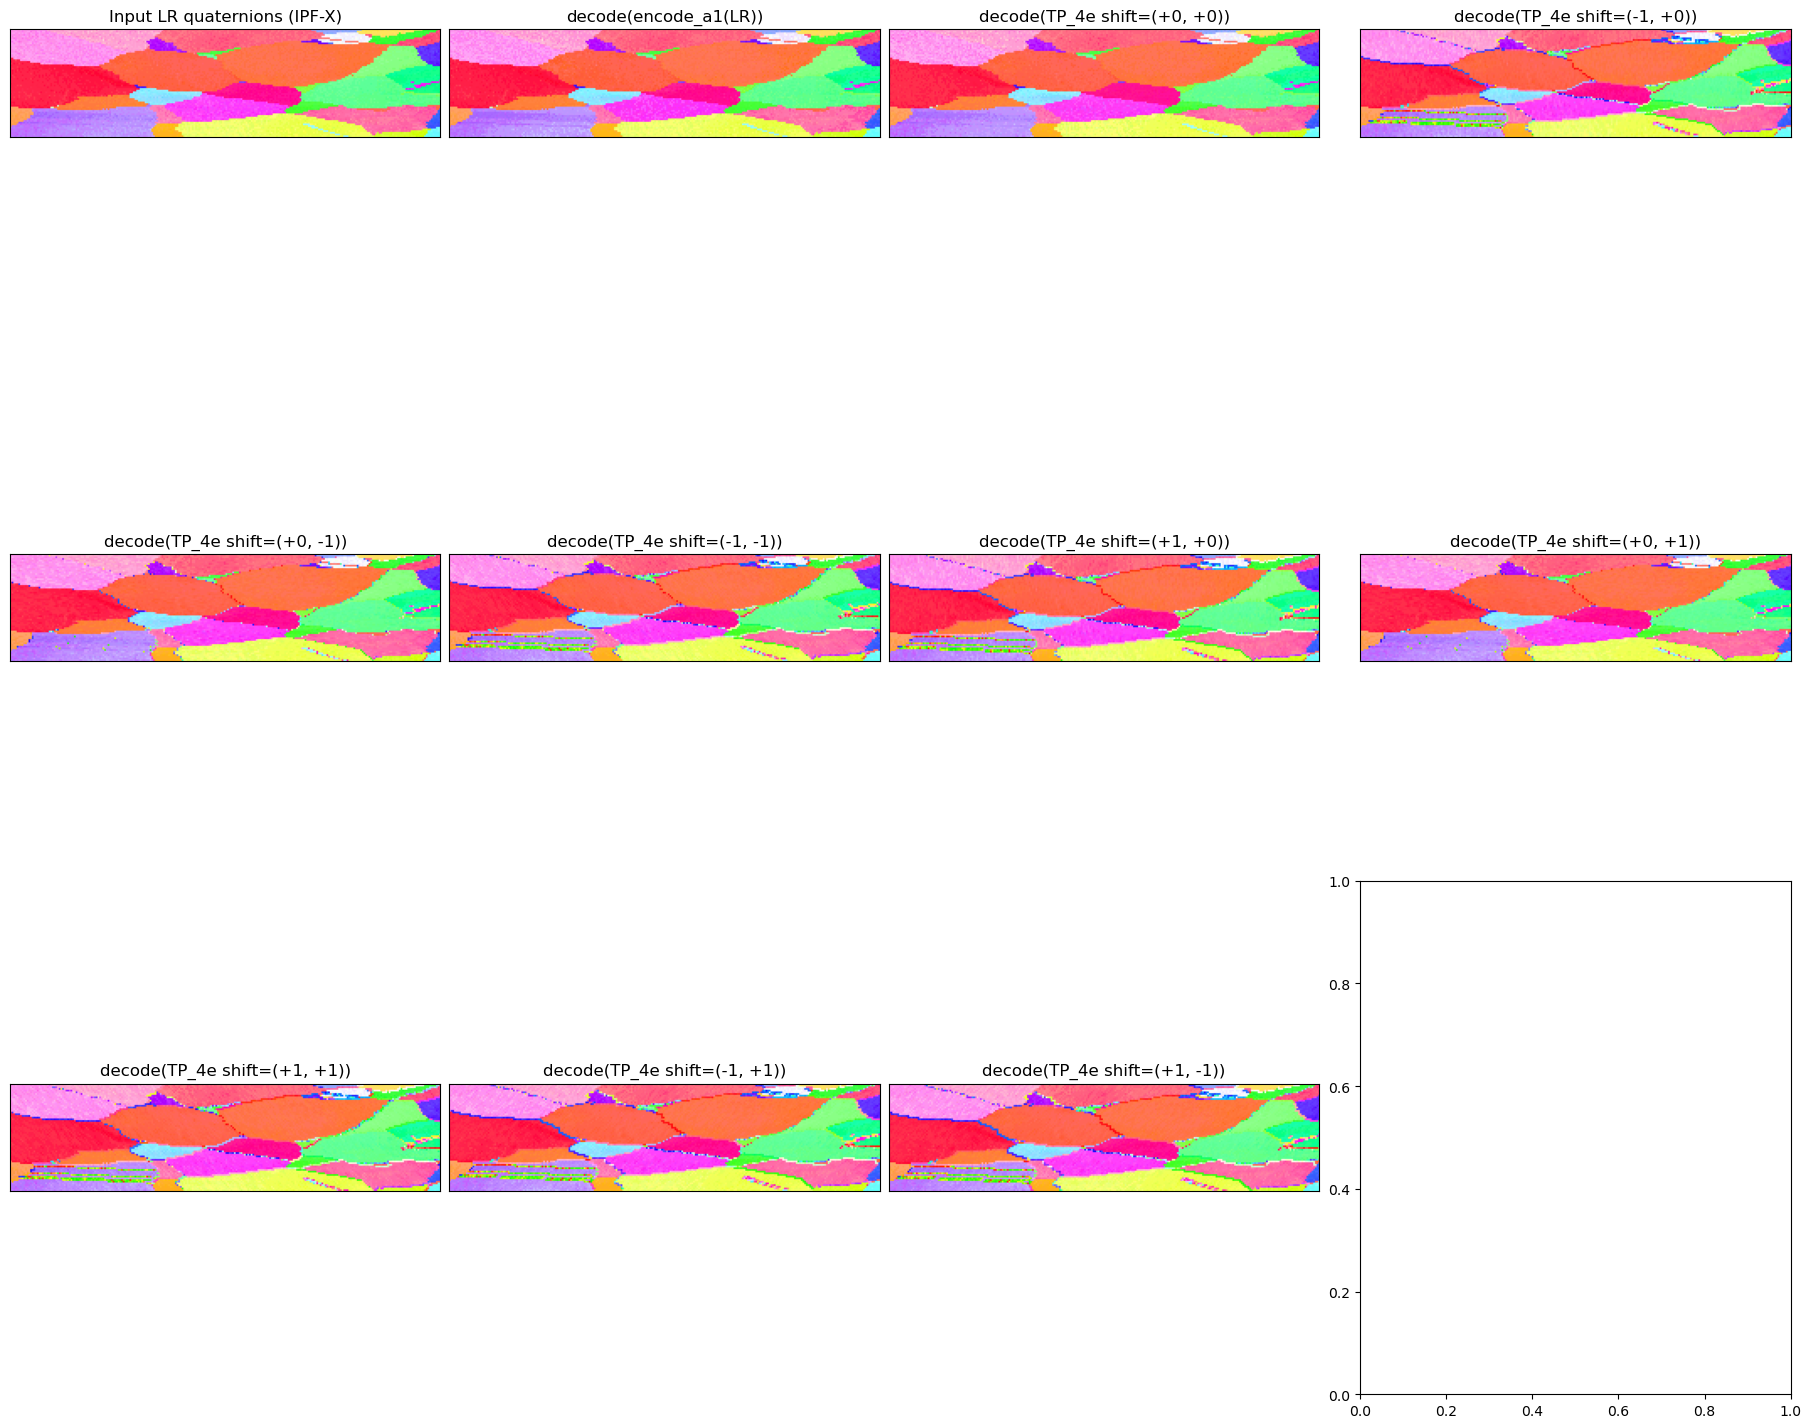

In [4]:
lr_quat_np = lr_quat.detach().cpu().numpy().astype(np.float32)
decoded_ref_np = decoded_ref.numpy().astype(np.float32)

panel_specs = [
    ('Input LR quaternions (IPF-X)', render_ipf_rgb(lr_quat_np, sym_class, ref_dir='X')),
    ('decode(encode_a1(LR))', render_ipf_rgb(decoded_ref_np, sym_class, ref_dir='X')),
]

for offset in OFFSETS:
    decoded_np = decoded_tp_by_offset[offset].numpy().astype(np.float32)
    title = f'decode(TP_4e shift={offset_label(offset)})'
    panel_specs.append((title, render_ipf_rgb(decoded_np, sym_class, ref_dir='X')))

fig, axes = plt.subplots(3, 4, figsize=(18, 16), constrained_layout=True)
for ax, (title, rgb) in zip(axes.ravel(), panel_specs):
    ax.imshow(rgb)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()


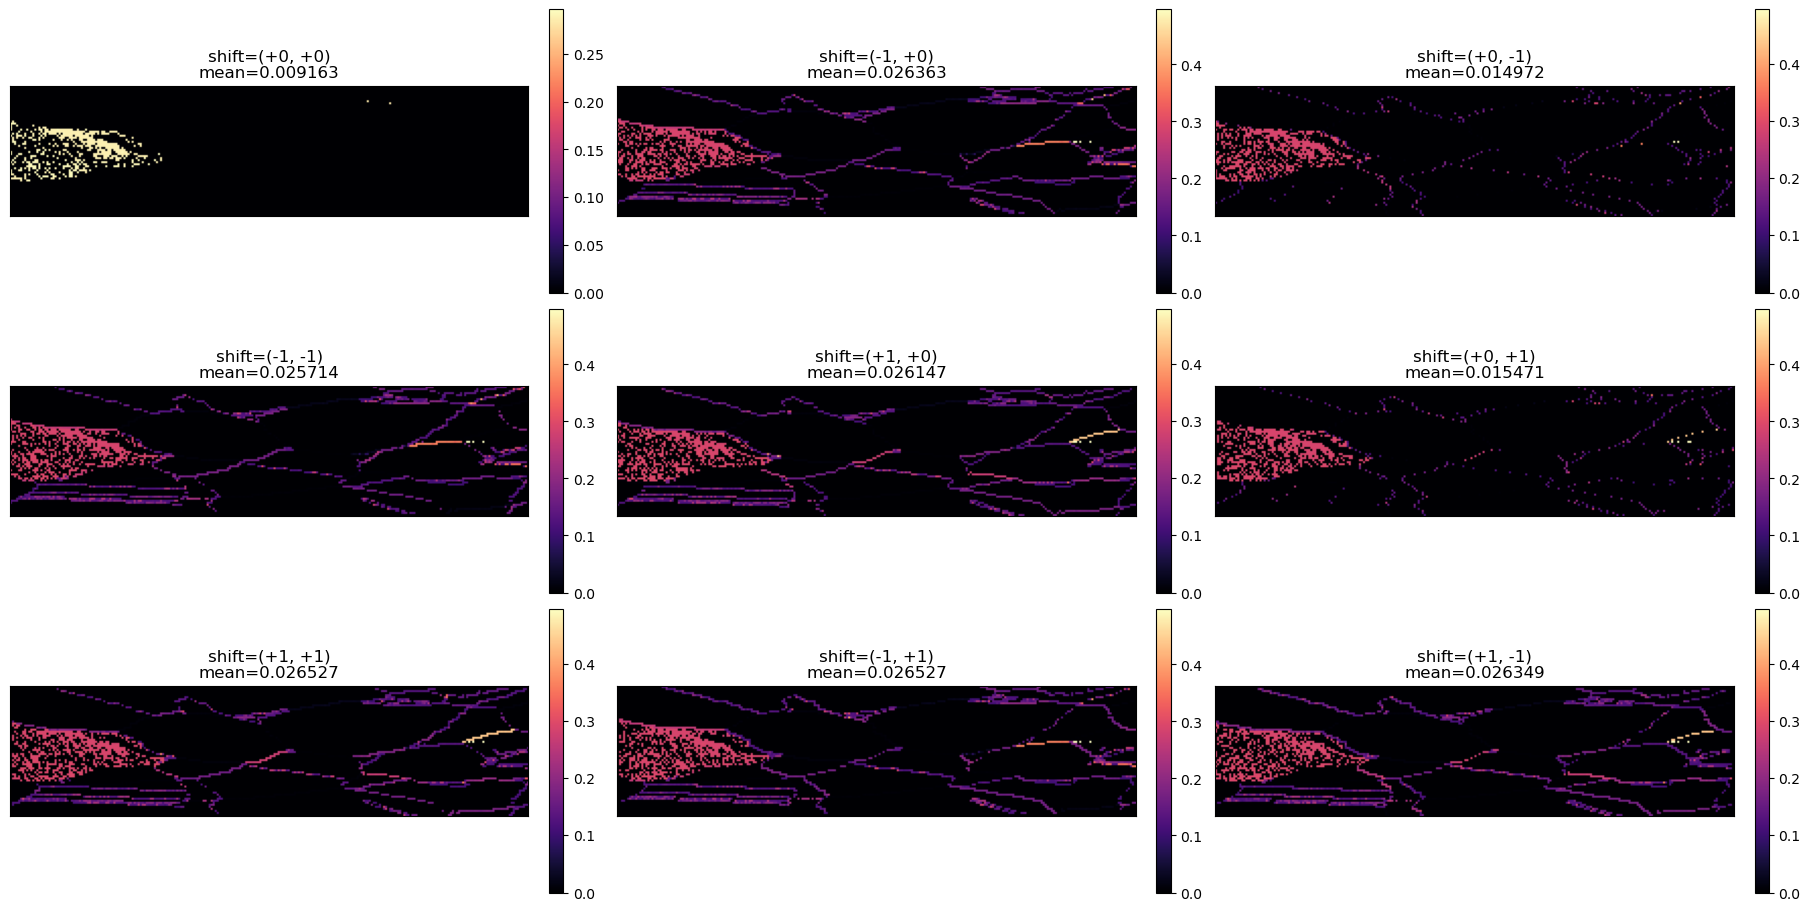

TP RMS by irrep and decoded-change summary:
--- shift=(+0, +0)
mean decoded change: 0.009163
    1x0e  rms=0.050000
    1x1e  rms=0.000000
    1x2e  rms=0.000000
    1x3e  rms=0.000000
    1x4e  rms=0.071693
    1x5e  rms=0.000000
    1x6e  rms=0.095346
    1x7e  rms=0.000000
    1x8e  rms=0.075955

--- shift=(-1, +0)
mean decoded change: 0.026363
    1x0e  rms=0.047119
    1x1e  rms=0.008597
    1x2e  rms=0.013229
    1x3e  rms=0.016953
    1x4e  rms=0.069744
    1x5e  rms=0.017478
    1x6e  rms=0.091457
    1x7e  rms=0.024337
    1x8e  rms=0.074948

--- shift=(+0, -1)
mean decoded change: 0.014972
    1x0e  rms=0.049289
    1x1e  rms=0.004634
    1x2e  rms=0.006533
    1x3e  rms=0.008388
    1x4e  rms=0.071183
    1x5e  rms=0.009022
    1x6e  rms=0.094398
    1x7e  rms=0.012020
    1x8e  rms=0.075712

--- shift=(-1, -1)
mean decoded change: 0.025714
    1x0e  rms=0.047002
    1x1e  rms=0.008880
    1x2e  rms=0.013596
    1x3e  rms=0.017104
    1x4e  rms=0.069613
    1x5e  rms=0.01812

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 9), constrained_layout=True)
axes_flat = axes.ravel()

for ax, offset in zip(axes_flat, OFFSETS):
    change_map = change_by_offset[offset].numpy()
    im = ax.imshow(change_map, cmap='magma')
    ax.set_title(f'shift={offset_label(offset)}\nmean={change_map.mean():.6f}')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes_flat[len(OFFSETS):]:
    ax.axis('off')

plt.show()

print('TP RMS by irrep and decoded-change summary:')
for offset in OFFSETS:
    print(f'--- shift={offset_label(offset)}')
    print(f'mean decoded change: {float(change_by_offset[offset].mean()):.6f}')
    for name, val in irrep_rms_table(tp_out_by_offset[offset].detach().cpu(), tp_full.irreps_out):
        print(f'  {name:>6s}  rms={val:.6f}')
    print()


In [6]:
stitched_hr_seed_feat = stitch_offset_feature_maps(
    feat_by_offset=tp_feat_by_offset,
    offset_order=SEED_STITCH_OFFSETS,
)

decoded_hr_seed_stitched = decode_feat_hwc_chunked(model, stitched_hr_seed_feat).detach().cpu()

print('seed stitch offsets:', SEED_STITCH_OFFSETS)
print('stitched_hr_seed_feat shape:', tuple(stitched_hr_seed_feat.shape))
print('decoded_hr_seed_stitched shape:', tuple(decoded_hr_seed_stitched.shape))


seed stitch offsets: [(-1, 0), (0, 1), (1, 0), (0, 0)]
stitched_hr_seed_feat shape: (256, 256, 9)
decoded_hr_seed_stitched shape: (256, 256, 4)


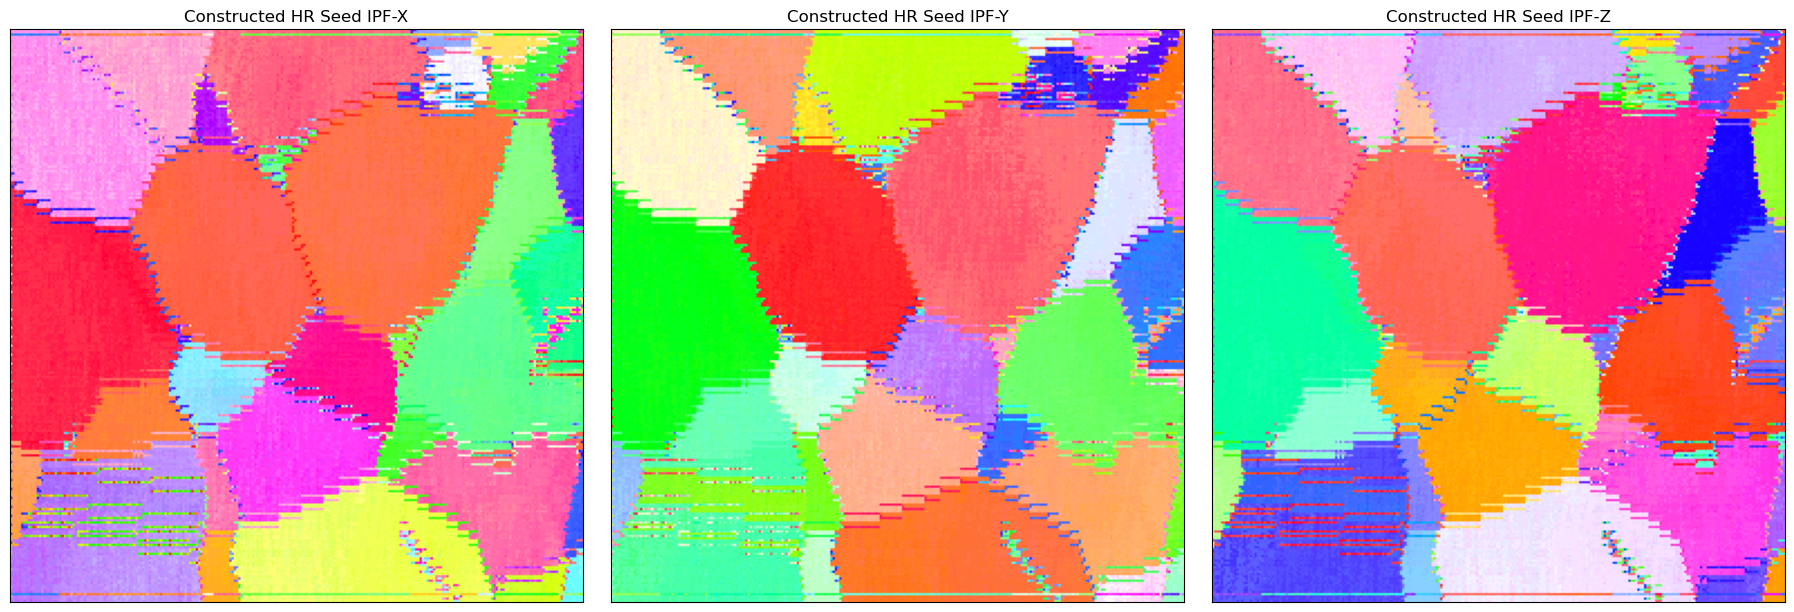

In [7]:
seed_rgb_x, seed_rgb_y, seed_rgb_z = render_ipf_rgb(
    decoded_hr_seed_stitched.numpy().astype(np.float32),
    sym_class,
    ref_dir='ALL',
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for ax, name, rgb in zip(
    axes,
    ['IPF-X', 'IPF-Y', 'IPF-Z'],
    [seed_rgb_x, seed_rgb_y, seed_rgb_z],
):
    ax.imshow(rgb)
    ax.set_title(f'Constructed HR Seed {name}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()


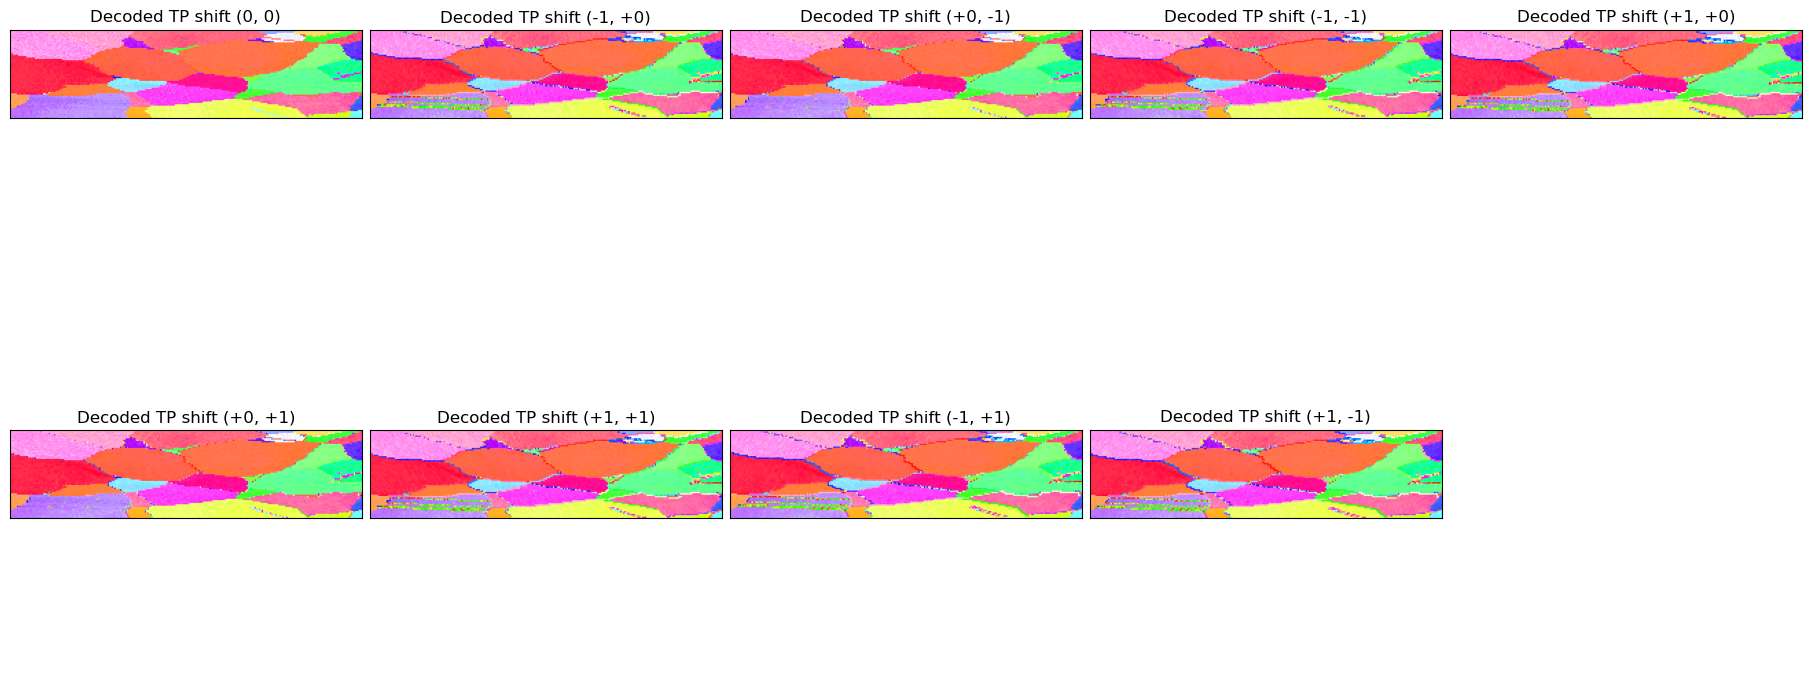

In [8]:
# Visualize decoded TP for (0,0) and all other shifts
import matplotlib.pyplot as plt

# Prepare panel specs: (0,0) first, then all other offsets
panel_specs = [
    (f"Decoded TP shift (0, 0)", decoded_tp_by_offset[(0, 0)].numpy().astype(np.float32))
]
for offset in OFFSETS:
    if offset != (0, 0):
        panel_specs.append((f"Decoded TP shift {offset_label(offset)}", decoded_tp_by_offset[offset].numpy().astype(np.float32)))

fig, axes = plt.subplots(2, (len(panel_specs) + 1) // 2, figsize=(18, 8), constrained_layout=True)
axes = axes.ravel()

for ax, (title, decoded_np) in zip(axes, panel_specs):
    rgb = render_ipf_rgb(decoded_np, sym_class, ref_dir='X')
    ax.imshow(rgb)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[len(panel_specs):]:
    ax.axis('off')

plt.show()

## Interpretation

The HR seed is now constructed by stitching, not averaging.

Current construction:

1. Compute TP-produced `4e` LR feature maps for the chosen offsets.
2. Select four LR maps in this fixed order:
   `SEED_STITCH_OFFSETS = [(-1,0), (0,1), (1,0), (0,0)]`
3. Treat those four LR maps as the four row-phases inside each LR row block.
4. Stitch them into a `4H x W` feature map by placing, for each LR row `y`, the four maps contiguously as HR rows
   `[map_0[y], map_1[y], map_2[y], map_3[y]]`.
5. Decode that stitched `4H x W` feature map directly to get the visualizable HR seed.

So this seed is no longer a bilinearly upsampled blend. It is a row-wise stitched HR feature map built from four separate LR TP maps.


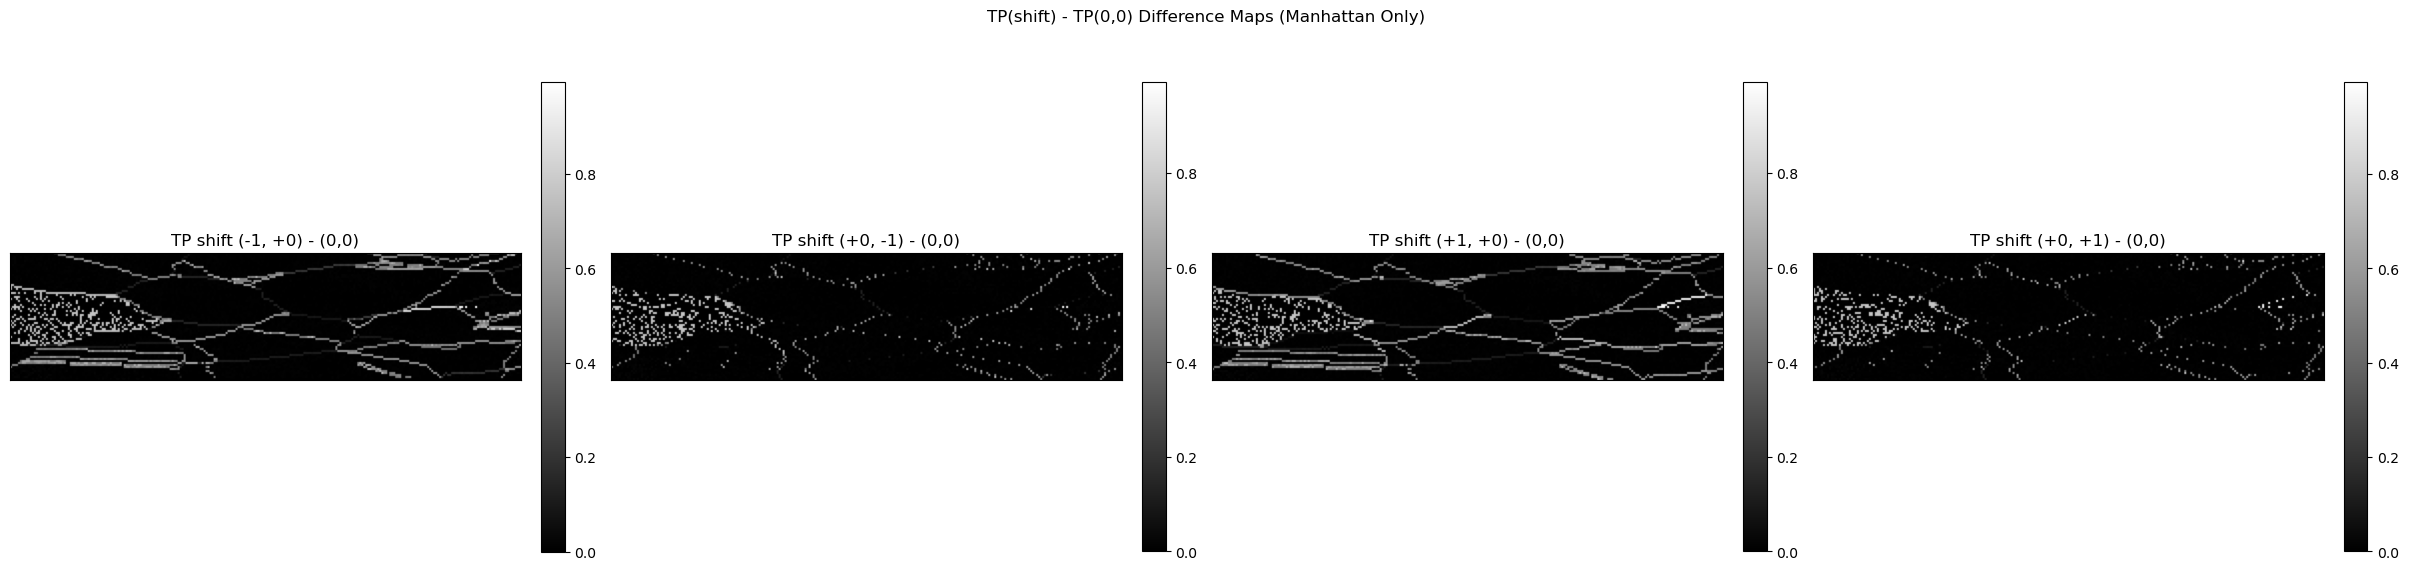

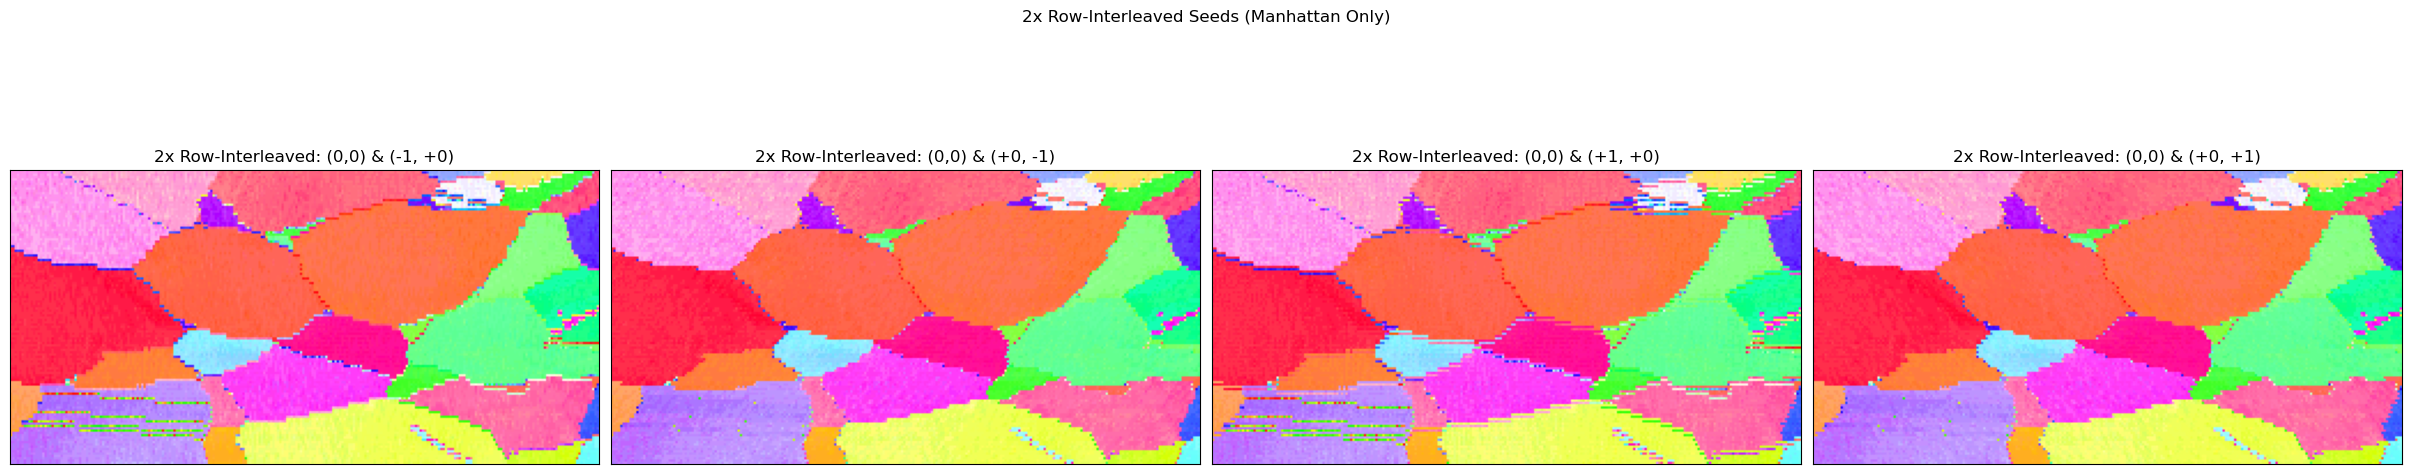

In [12]:
# --- 2x Upsampling: TP Difference and Row-Interleaved Visualization (Manhattan Only, Stitched Row) ---
import matplotlib.pyplot as plt

# Define Manhattan offsets (no diagonals)
manhattan_offsets = [offset for offset in OFFSETS if (offset != (0, 0)) and (abs(offset[0]) + abs(offset[1]) == 1)]

# Get the reference TP (0,0)
tp_ref = decoded_tp_by_offset[(0, 0)].numpy().astype(np.float32)
H, W, C = tp_ref.shape

# 1. Show difference maps: TP(shift) - TP(0,0)
diff_panel_specs = []
for offset in manhattan_offsets:
    tp_shift = decoded_tp_by_offset[offset].numpy().astype(np.float32)
    diff = tp_shift - tp_ref
    diff_panel_specs.append((f"TP shift {offset_label(offset)} - (0,0)", diff))

fig, axes = plt.subplots(1, len(diff_panel_specs), figsize=(6 * len(diff_panel_specs), 6), constrained_layout=True)
if len(diff_panel_specs) == 1:
    axes = [axes]
for ax, (title, diff) in zip(axes, diff_panel_specs):
    # Show norm of difference as grayscale
    diff_norm = (diff ** 2).sum(axis=-1) ** 0.5
    im = ax.imshow(diff_norm, cmap='gray')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for ax in axes[len(diff_panel_specs):]:
    ax.axis('off')
plt.suptitle('TP(shift) - TP(0,0) Difference Maps (Manhattan Only)')
plt.show()

# 2. Row-interleaved 2x upsampled seeds: alternate rows from (0,0) and shift, show all in one row
stitched_rgbs = []
stitched_titles = []
for offset in manhattan_offsets:
    tp_shift = decoded_tp_by_offset[offset].numpy().astype(np.float32)
    upsampled = np.empty((H * 2, W, 4), dtype=np.float32)
    upsampled[0::2, :, :] = tp_ref
    upsampled[1::2, :, :] = tp_shift
    rgb = render_ipf_rgb(upsampled, sym_class, ref_dir='X')
    stitched_rgbs.append(rgb)
    stitched_titles.append(f'2x Row-Interleaved: (0,0) & {offset_label(offset)}')

fig, axes = plt.subplots(1, len(stitched_rgbs), figsize=(6 * len(stitched_rgbs), 6), constrained_layout=True)
if len(stitched_rgbs) == 1:
    axes = [axes]
for ax, rgb, title in zip(axes, stitched_rgbs, stitched_titles):
    ax.imshow(rgb)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axes[len(stitched_rgbs):]:
    ax.axis('off')
plt.suptitle('2x Row-Interleaved Seeds (Manhattan Only)')
plt.show()

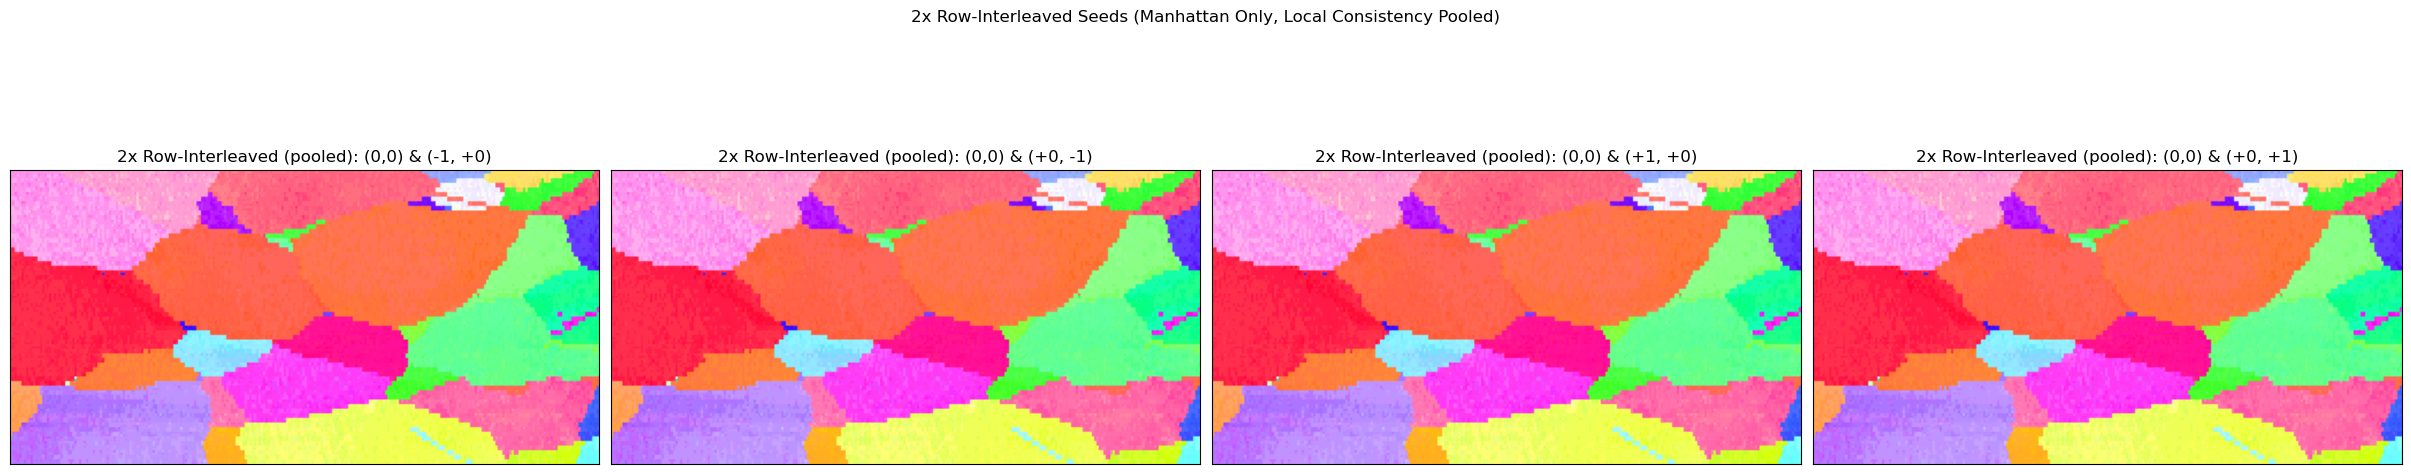

In [13]:
# --- Local Consistency Pooling for Row-Interleaved Upsampling (Manhattan Only) ---
# For each odd row (those using a nonzero shift), select the feature from the 4 Manhattan-shifted TP maps
# whose feature is closest to any pixel in the 3x3 neighborhood of the corresponding TP(0,0) map.
# This is done BEFORE stitching/interleaving.

import numpy as np

# Manhattan offsets (no diagonals, nonzero)
manhattan_offsets = [offset for offset in OFFSETS if (offset != (0, 0)) and (abs(offset[0]) + abs(offset[1]) == 1)]

# Get decoded TP maps for all 4 Manhattan offsets and (0,0)
decoded_maps = [(offset, decoded_tp_by_offset[offset].numpy().astype(np.float32)) for offset in [(0,0)] + manhattan_offsets]

# Reference TP(0,0) map
ref_map = decoded_tp_by_offset[(0,0)].numpy().astype(np.float32)  # shape (H, W, C)
H, W, C = ref_map.shape

# For each Manhattan offset, build a new upsampled map using local consistency pooling for odd rows
pooled_upsampled_rgbs = []
pooled_upsampled_titles = []

for offset, tp_map in decoded_maps[1:]:  # skip (0,0) for pooling
    # Create upsampled array: even rows from TP(0,0), odd rows from pooled selection
    upsampled = np.empty((H * 2, W, C), dtype=np.float32)
    upsampled[0::2, :, :] = ref_map  # even rows: always TP(0,0)
    # Odd rows: for each pixel, select the best feature among all 4 maps
    for y in range(H):
        for x in range(W):
            # For this HR pixel (odd row), gather candidates from all 4 Manhattan maps
            candidates = [decoded_tp_by_offset[off].numpy().astype(np.float32)[y, x] for off in manhattan_offsets]
            # 3x3 neighborhood in TP(0,0)
            y0, x0 = y, x
            y_min, y_max = max(0, y0-1), min(H-1, y0+1)
            x_min, x_max = max(0, x0-1), min(W-1, x0+1)
            ref_patch = ref_map[y_min:y_max+1, x_min:x_max+1, :]  # shape (<=3, <=3, C)
            ref_patch_flat = ref_patch.reshape(-1, C)
            # For each candidate, compute min L2 distance to any pixel in ref_patch
            dists = [np.min(np.linalg.norm(cand - ref_patch_flat, axis=1)) for cand in candidates]
            best_idx = np.argmin(dists)
            upsampled[2*y+1, x, :] = candidates[best_idx]
    # Visualize
    rgb = render_ipf_rgb(upsampled, sym_class, ref_dir='X')
    pooled_upsampled_rgbs.append(rgb)
    pooled_upsampled_titles.append(f'2x Row-Interleaved (pooled): (0,0) & {offset_label(offset)}')

# Plot all pooled upsampled maps in one row
fig, axes = plt.subplots(1, len(pooled_upsampled_rgbs), figsize=(6 * len(pooled_upsampled_rgbs), 6), constrained_layout=True)
if len(pooled_upsampled_rgbs) == 1:
    axes = [axes]
for ax, rgb, title in zip(axes, pooled_upsampled_rgbs, pooled_upsampled_titles):
    ax.imshow(rgb)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axes[len(pooled_upsampled_rgbs):]:
    ax.axis('off')
plt.suptitle('2x Row-Interleaved Seeds (Manhattan Only, Local Consistency Pooled)')
plt.show()


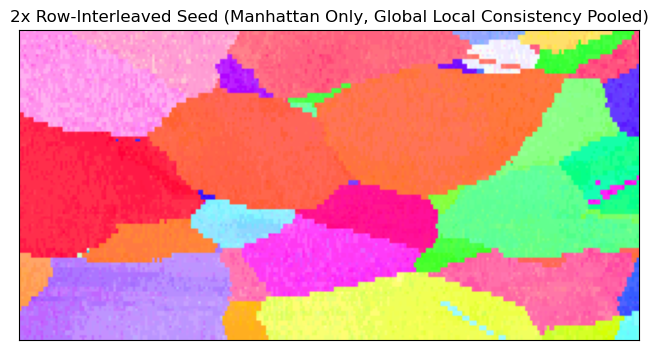

In [14]:
# --- Single HR 2x Map by Global Local Consistency Pooling (Manhattan Only) ---
# For each odd row, for each pixel, select the best feature among ALL 4 Manhattan-shifted TP maps
# whose feature is closest to any pixel in the 3x3 neighborhood of the corresponding TP(0,0) map.
# This produces a single HR 2x map.

import numpy as np

# Manhattan offsets (no diagonals, nonzero)
manhattan_offsets = [offset for offset in OFFSETS if (offset != (0, 0)) and (abs(offset[0]) + abs(offset[1]) == 1)]

# Reference TP(0,0) map
ref_map = decoded_tp_by_offset[(0,0)].numpy().astype(np.float32)  # shape (H, W, C)
H, W, C = ref_map.shape

# Precompute all 4 Manhattan-shifted TP maps
manhattan_maps = [decoded_tp_by_offset[off].numpy().astype(np.float32) for off in manhattan_offsets]

# Create upsampled array: even rows from TP(0,0), odd rows from pooled selection
upsampled = np.empty((H * 2, W, C), dtype=np.float32)
upsampled[0::2, :, :] = ref_map  # even rows: always TP(0,0)

# Odd rows: for each pixel, select the best feature among all 4 Manhattan maps
for y in range(H):
    for x in range(W):
        # For this HR pixel (odd row), gather candidates from all 4 Manhattan maps
        candidates = [manhattan_maps[i][y, x] for i in range(4)]
        # 3x3 neighborhood in TP(0,0)
        y0, x0 = y, x
        y_min, y_max = max(0, y0-1), min(H-1, y0+1)
        x_min, x_max = max(0, x0-1), min(W-1, x0+1)
        ref_patch = ref_map[y_min:y_max+1, x_min:x_max+1, :]  # shape (<=3, <=3, C)
        ref_patch_flat = ref_patch.reshape(-1, C)
        # For each candidate, compute min L2 distance to any pixel in ref_patch
        dists = [np.min(np.linalg.norm(cand - ref_patch_flat, axis=1)) for cand in candidates]
        best_idx = np.argmin(dists)
        upsampled[2*y+1, x, :] = candidates[best_idx]

# Visualize
rgb = render_ipf_rgb(upsampled, sym_class, ref_dir='X')
plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title('2x Row-Interleaved Seed (Manhattan Only, Global Local Consistency Pooled)')
plt.xticks([])
plt.yticks([])
plt.show()


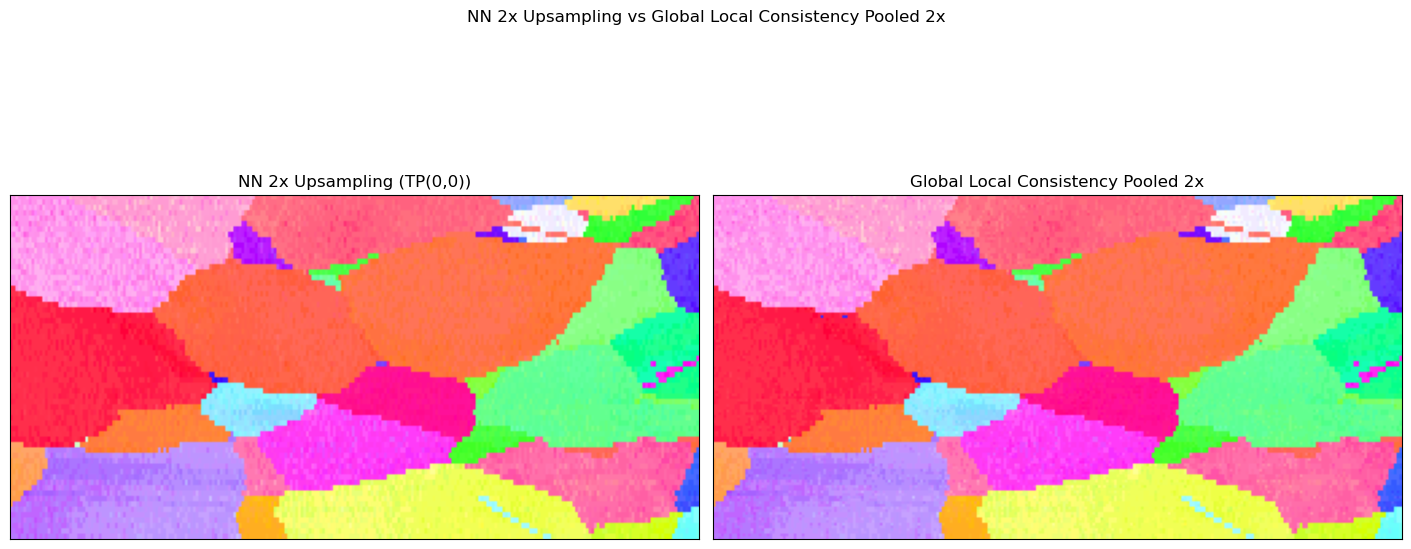

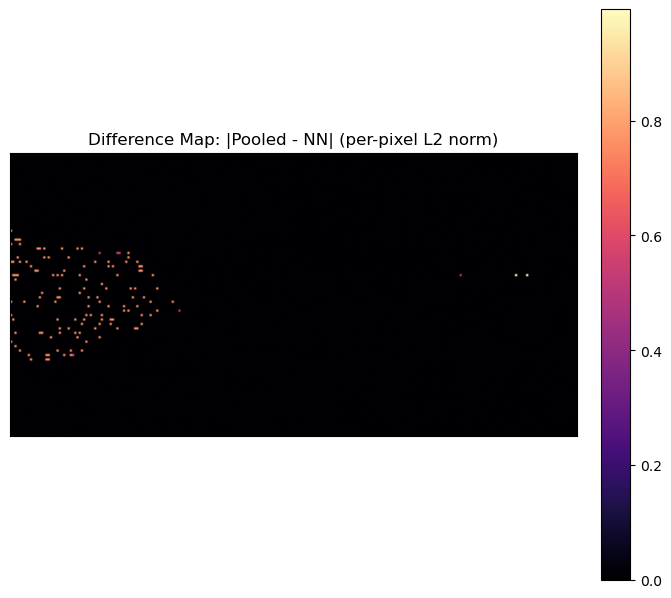

In [15]:
# --- Compare Global Local Consistency Pooled HR 2x Map to NN 2x Upsampling and Show Difference Map ---
# 1. NN (nearest neighbor) upsampling of TP(0,0) feature map
# 2. Visualize side by side with pooled map
# 3. Show difference map (norm per pixel)

# 1. NN upsampling (repeat each row twice)
ref_map = decoded_tp_by_offset[(0,0)].numpy().astype(np.float32)  # (H, W, C)
H, W, C = ref_map.shape
nn_upsampled = np.repeat(ref_map, 2, axis=0)  # (H*2, W, C)

# 2. Visualize side by side
rgb_nn = render_ipf_rgb(nn_upsampled, sym_class, ref_dir='X')
rgb_pooled = render_ipf_rgb(upsampled, sym_class, ref_dir='X')

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
axes[0].imshow(rgb_nn)
axes[0].set_title('NN 2x Upsampling (TP(0,0))')
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[1].imshow(rgb_pooled)
axes[1].set_title('Global Local Consistency Pooled 2x')
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.suptitle('NN 2x Upsampling vs Global Local Consistency Pooled 2x')
plt.show()

# 3. Show difference map (norm per pixel)
diff = np.linalg.norm(upsampled - nn_upsampled, axis=-1)
plt.figure(figsize=(8, 8))
plt.imshow(diff, cmap='magma')
plt.title('Difference Map: |Pooled - NN| (per-pixel L2 norm)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks([])
plt.yticks([])
plt.show()


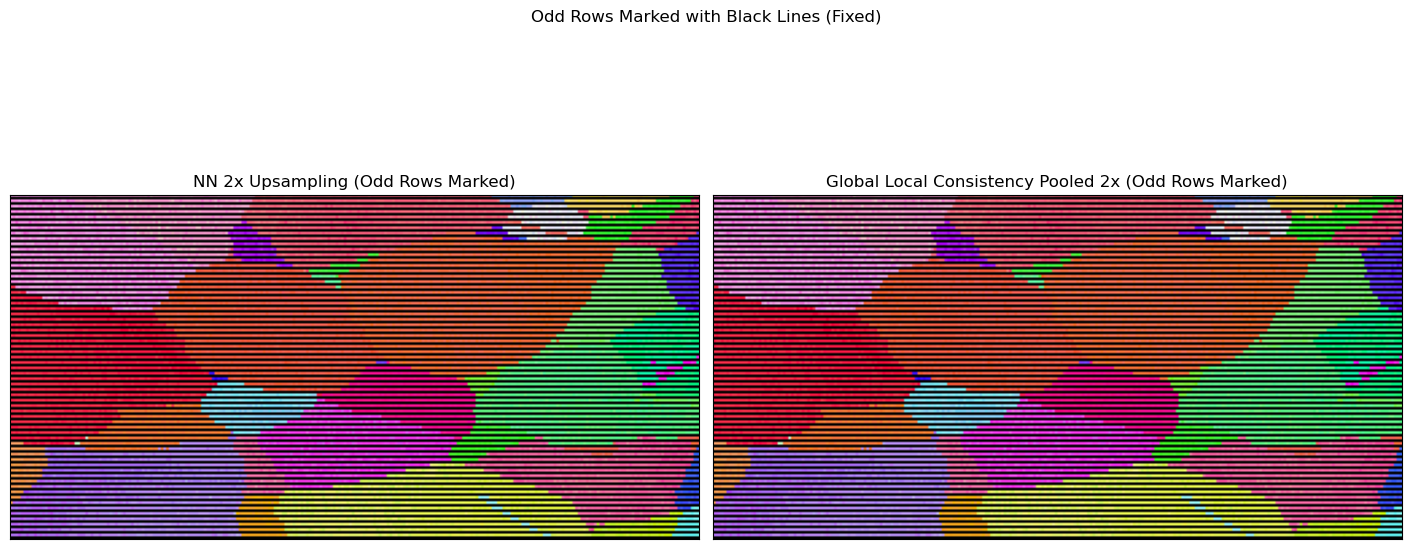

In [17]:
# --- Visualize Odd Rows with Black Outlines on Both NN and Pooled Images (Fixed) ---
# Overlay a single horizontal black line at the top of each odd row

def overlay_odd_row_lines(rgb_img, thickness=1):
    """Overlay a black line at the top of each odd row (optionally thicker)."""
    img = rgb_img.copy()
    H = img.shape[0]
    for y in range(1, H, 2):
        img[y:y+thickness, :, :] = 0  # only the top edge of the odd row
    return img

rgb_nn_marked = overlay_odd_row_lines(rgb_nn, thickness=1)
rgb_pooled_marked = overlay_odd_row_lines(rgb_pooled, thickness=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
axes[0].imshow(rgb_nn_marked)
axes[0].set_title('NN 2x Upsampling (Odd Rows Marked)')
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[1].imshow(rgb_pooled_marked)
axes[1].set_title('Global Local Consistency Pooled 2x (Odd Rows Marked)')
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.suptitle('Odd Rows Marked with Black Lines (Fixed)')
plt.show()
